In [9]:
import pandas as pd

df = pd.read_csv("Combined_Medical_Insurance_Dataset.csv")

In [10]:
df.head()

,Name,Age,Gender/Sex,Location,Hobbies,Medical Condition
0,Aadhya A. Bhat,29,Female,Pune,"Gardening, Walking",Osteoporosis
1,Aadhya A. Chowdhury,24,Male,Visakhapatnam,"Swimming, Photography",Thyroid Disorder
2,Aadhya A. Malhotra,34,Female,Hubballi,Badminton,Respiratory Infection
3,Aadhya A. Patel,38,Female,Vijayawada,"Music, Swimming",Chronic Back Pain
4,Aadhya A. Singh,19,Female,Hyderabad,"Walking, Swimming",Depression


In [11]:
# Dataset shape
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])

Rows: 57838
Columns: 6


In [12]:
# Column names
df.columns.tolist()

['Name', 'Age', 'Gender/Sex', 'Location', 'Hobbies', 'Medical Condition']

In [13]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 57838 entries, 0 to 57837
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Name               57838 non-null  str  
 1   Age                57838 non-null  int64
 2   Gender/Sex         56838 non-null  str  
 3   Location           57838 non-null  str  
 4   Hobbies            57838 non-null  str  
 5   Medical Condition  57838 non-null  str  
dtypes: int64(1), str(5)
memory usage: 2.6 MB


In [14]:
# Basic statistical summary
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Name,57838,52330,DAvId muNoZ,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,57838.0,NaN,NaN,NaN,51.036464,19.512458,13.0,34.0,51.0,68.0,89.0
Gender/Sex,56838,2,Male,28450,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,57838,22,Mangaluru,3790,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hobbies,57838,15,"Gardening, Walking",3856,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medical Condition,57838,23,Arthritis,9420,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# Check for missing values
df.isnull().sum()

Name                    0
Age                     0
Gender/Sex           1000
Location                0
Hobbies                 0
Medical Condition       0
dtype: int64

In [16]:
# Display the complete dataset
df

,Name,Age,Gender/Sex,Location,Hobbies,Medical Condition
0,Aadhya A. Bhat,29,Female,Pune,"Gardening, Walking",Osteoporosis
1,Aadhya A. Chowdhury,24,Male,Visakhapatnam,"Swimming, Photography",Thyroid Disorder
2,Aadhya A. Malhotra,34,Female,Hubballi,Badminton,Respiratory Infection
3,Aadhya A. Patel,38,Female,Vijayawada,"Music, Swimming",Chronic Back Pain
4,Aadhya A. Singh,19,Female,Hyderabad,"Walking, Swimming",Depression
...,...,...,...,...,...,...
57833,Zoe Jackson,38,Male,Hubballi,"Football, Badminton",Asthma
57834,ZoE ROdRiGuEz,53,Female,Hyderabad,"Music, Swimming",Cancer
57835,ZoE ROdRiGuEz,53,Female,Delhi,"Photography, Gardening",Cancer
57836,Zoe SmITh,36,Male,Pune,"Travelling, Walking",Obesity


In [17]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
print(df["Medical Condition"].value_counts())

Medical Condition
Arthritis                                 9420
Hypertension                              9357
Obesity                                   9343
Diabetes                                  9304
Asthma                                    9297
Cancer                                    9227
High Cholesterol                           112
Migraine                                   112
Type 2 Diabetes                            112
Osteoporosis                               111
Thyroid Disorder                           111
Respiratory Infection                      111
Chronic Back Pain                          111
Depression                                 111
Fatty Liver Disease                        111
Anemia                                     111
Allergic Rhinitis                          111
Heart Disease                              111
Chronic Kidney Disease                     111
Vitamin D Deficiency                       111
Gastritis                                 

In [19]:
# Features
X = df.drop(columns=["Medical Condition", "Name"])

# Target
y = df["Medical Condition"]

print("Features:")
print(X.columns.tolist())

print("\nTarget classes:")
print(y.unique())

Features:
['Age', 'Gender/Sex', 'Location', 'Hobbies']

Target classes:
<StringArray>
[                          'Osteoporosis',
                       'Thyroid Disorder',
                  'Respiratory Infection',
                      'Chronic Back Pain',
                             'Depression',
                       'High Cholesterol',
                              'Arthritis',
                    'Fatty Liver Disease',
                                 'Asthma',
                                 'Anemia',
                               'Migraine',
                      'Allergic Rhinitis',
                          'Heart Disease',
                        'Type 2 Diabetes',
                 'Chronic Kidney Disease',
                   'Vitamin D Deficiency',
                                'Obesity',
                           'Hypertension',
                              'Gastritis',
 'Gastroesophageal Reflux Disease (GERD)',
                                 'Cancer',
           

In [20]:
numeric_features = ["Age"]

categorical_features = [
    "Gender/Sex",
    "Location",
    "Hobbies"
]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (46270, 4)
Testing data: (11568, 4)


In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [23]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [24]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

In [25]:
print("Training the model...")

pipeline.fit(X_train, y_train)

print("✅ Model training completed!")

Training the model...
✅ Model training completed!


In [26]:
y_pred = pipeline.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [27]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 15.89%


In [28]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 15.89%


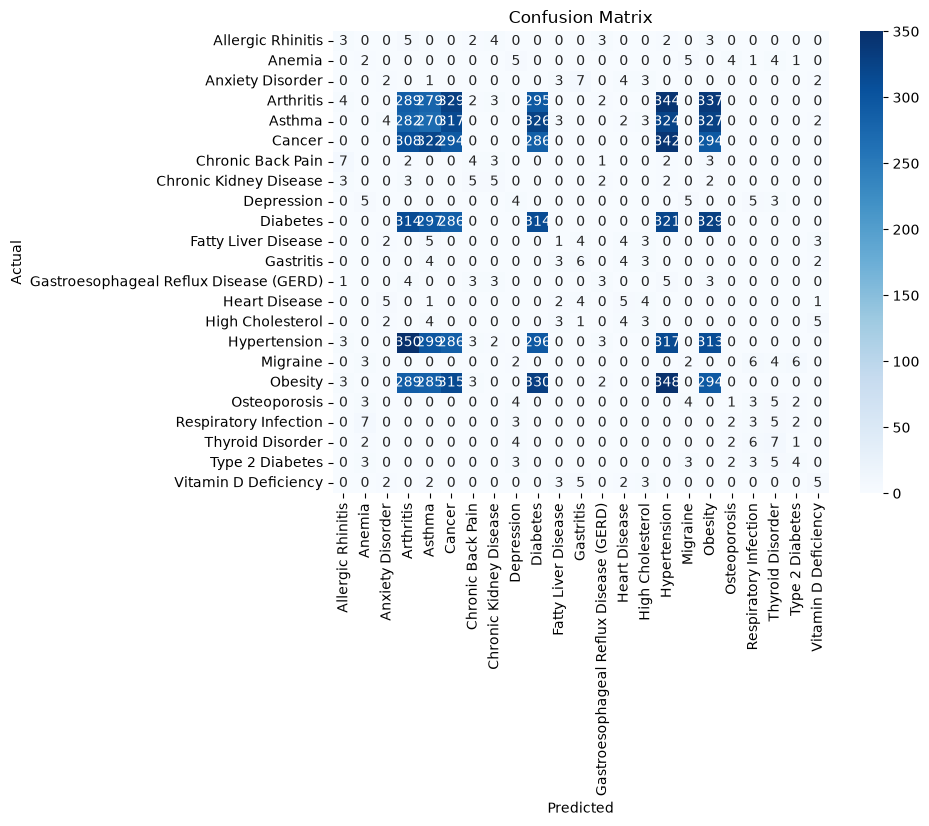

In [29]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=pipeline.classes_,
    yticklabels=pipeline.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [30]:
new_patient = pd.DataFrame({
    "Age": [35],
    "Gender/Sex": ["Male"],
    "Location": ["California"],
    "Hobbies": ["Reading"]
})

prediction = pipeline.predict(new_patient)

print("Predicted Medical Condition:", prediction[0])

Predicted Medical Condition: Asthma


In [31]:
import joblib

joblib.dump(pipeline, "medical_insurance_model.pkl")

print("✅ Model saved as medical_insurance_model.pkl")

✅ Model saved as medical_insurance_model.pkl


In [32]:
# Check how strongly each feature is related to Medical Condition

print("Medical Condition distribution:")
print(df["Medical Condition"].value_counts())

print("\nGender vs Medical Condition:")
print(pd.crosstab(
    df["Gender/Sex"],
    df["Medical Condition"],
    normalize="index"
).round(3))

print("\nLocation vs Medical Condition:")
print(pd.crosstab(
    df["Location"],
    df["Medical Condition"],
    normalize="index"
).round(3))

print("\nHobbies vs Medical Condition:")
print(pd.crosstab(
    df["Hobbies"],
    df["Medical Condition"],
    normalize="index"
).round(3))

Medical Condition distribution:
Medical Condition
Arthritis                                 9420
Hypertension                              9357
Obesity                                   9343
Diabetes                                  9304
Asthma                                    9297
Cancer                                    9227
High Cholesterol                           112
Migraine                                   112
Type 2 Diabetes                            112
Osteoporosis                               111
Thyroid Disorder                           111
Respiratory Infection                      111
Chronic Back Pain                          111
Depression                                 111
Fatty Liver Disease                        111
Anemia                                     111
Allergic Rhinitis                          111
Heart Disease                              111
Chronic Kidney Disease                     111
Vitamin D Deficiency                       111
Gastritis 

In [33]:
age_analysis = df.groupby("Medical Condition")["Age"].agg(
    ["count", "mean", "std", "min", "max"]
)

age_analysis.sort_values("count", ascending=False)

,count,mean,std,min,max
Medical Condition,,,,,
Arthritis,9420,51.411571,19.602958,13,89
Hypertension,9357,51.592391,19.623746,13,89
Obesity,9343,51.101680,19.517531,13,89
Diabetes,9304,51.554170,19.425088,14,89
Asthma,9297,51.419598,19.688965,13,89
Cancer,9227,51.558795,19.659261,13,89
High Cholesterol,112,38.946429,12.881888,18,64
Type 2 Diabetes,112,38.553571,12.391394,18,64
Migraine,112,39.098214,12.241533,18,64
